### 016 - Coin FLip to Confirm Account

In [1]:
from qiskit import QuantumCircuit, transpile

from qiskit_ibm_runtime import (
    Batch,
    SamplerV2 as Sampler,
    QiskitRuntimeService,
)

import pylatexenc

In [2]:
# -------------------------------
# 1. Authenticate with IBM Quantum
# -------------------------------
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    instance="ptc_work", 
)

In [3]:
# -------------------------------
# 2. Choose a backend (Least busy) 
# -------------------------------

# Filter for real devices (exclude simulators) and those that are operational
backends = service.backends(
    simulator=False,
    operational=True
)

# Sort by queue length
least_busy = sorted(backends, key=lambda b: b.status().pending_jobs)[0]

backend = least_busy
print(f"Using least busy backend: {backend.name}")
print(f"Pending jobs: {backend.status().pending_jobs}")

Using least busy backend: ibm_fez
Pending jobs: 0


In [4]:
# -------------------------------
# 3. Build the coin‑flip circuit
# -------------------------------
qc = QuantumCircuit(1, 1)
qc.h(0)          # fair superposition
qc.measure(0, 0) # readout

Circuit Created


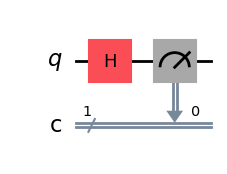

In [5]:
print("Circuit Created")
qc.draw('mpl')

Optimized Circuit Created


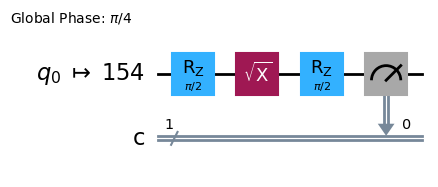

In [6]:
# transpile the circuit
transpiled_circuit = transpile(qc, backend=backend)

#construct  pub 
pub_qc_measurement = (transpiled_circuit) 

print("Optimized Circuit Created")
transpiled_circuit.draw('mpl')

In [8]:
# -------------------------------
# 4. Run with the Sampler primitive
# -------------------------------

# Inaitialize the sampler
sampler = Sampler(backend)
job_qc_measurement = sampler.run([pub_qc_measurement], shots=1500)

# Extract results
result_qc_measurement = job_qc_measurement.result()
data_qc_measurement = result_qc_measurement[0].data
print("qc Measurement Results:")
print(data_qc_measurement)

qc Measurement Results:
DataBin(c=BitArray(<shape=(), num_shots=1500, num_bits=1>))


In [9]:
# -----------------------------------------
# 4.1 Get Results 
# -----------------------------------------
quasi = result_qc_measurement[0].data
print(quasi)

DataBin(c=BitArray(<shape=(), num_shots=1500, num_bits=1>))
